<a href="https://colab.research.google.com/github/sireeshas2/data-science-final-year-project/blob/main/Data_Science_Project_2025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Customer Churn Prediction in the Telecommunications Industry using Machine Learning



The intent of the project "Customer churn prediction in the telecommunication industry using machine learning" is to put several advanced machine learning algorithms to work in predicting customer churn within the telecom sector. The assessment of the agreement among the advanced and traditional machine learning models will purpose to find out which of those methods work better for churn prediction. The essential demographic and usage features for producing churn behavior predictors will, therefore, be analyzed, supported by some interpretability tools, such as SHAP, to explain their respective predictions. Finally, the project will also examine how threshold tuning and probability calibration can be leveraged to optimize churn mitigation, providing actionable insights to telecom companies.


### **Dataset Details:**

- **Name:** BM Telco Customer Churn Dataset
- **Source:** [BM Telco Customer Churn Dataset on GitHub](https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv)
- **Contributors:** The dataset was collected by IBM as part of its internal analytics for a telecommunications business and later made publicly available via IBM’s internal GitHub for instructional and research purposes.



# **Step 1: Importing necessary Files**

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
import os, time
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_fscore_support, accuracy_score, average_precision_score, classification_report
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier


# **Step 2: Reading Dataset File**

In [2]:
file_path = '/content/WA_Fn-UseC_-Telco-Customer-Churn.csv'  # Path to the uploaded dataset
df_telco = pd.read_csv(file_path)

# **Step 3: Exploratory Data Analysis & Initial Preprocessing**

## **Printing first Few rows**

In [3]:
print("Dataset Head:")
df_telco.head()

Dataset Head:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## **Printing Shape of the Dataset**

In [4]:
print("Dataset Shape:")
df_telco.shape

Dataset Shape:


(7043, 21)

## **Printing Dataset Info**

In [5]:
print("Basic Info:")
df_telco.info()

Basic Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-nul

## **Descriptive Statisical Analysis**

In [6]:
print("\nSummary Statistics:")
df_telco.describe()


Summary Statistics:


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## **Checking for Missing values in Dataset**

In [7]:
print("\nMissing Values per Column:")
missing_values = df_telco.isnull().sum()  # Count missing values in each column
print(missing_values)


Missing Values per Column:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


## **Distribution of Numerical Features in dataset**

<Figure size 500x500 with 0 Axes>

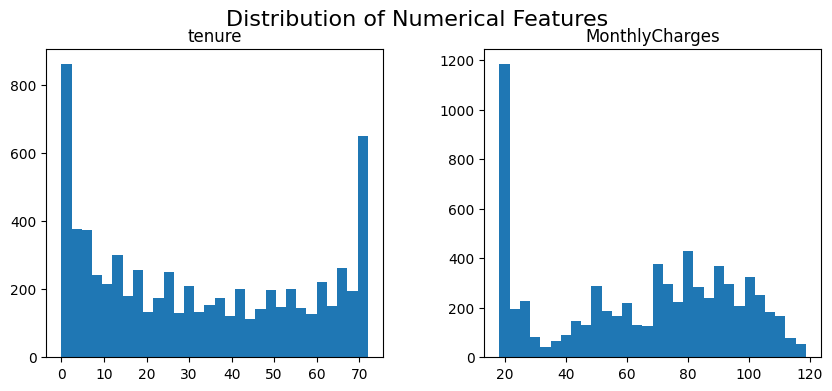

In [8]:
numerical_features = df_telco.select_dtypes(include=['float64', 'int64']).columns

# Remove 'SeniorCitizen' from the list
numerical_features = numerical_features.drop('SeniorCitizen', errors='ignore')

plt.figure(figsize=(5, 5))
df_telco[numerical_features].hist(bins=30, figsize=(10, 4), grid=False)
plt.suptitle('Distribution of Numerical Features ', fontsize=16)
plt.show()


## **Label Encoding the dataset and Printing Correlation Matrix**

Label Encoding is done to handle non-numeric values in the dataset

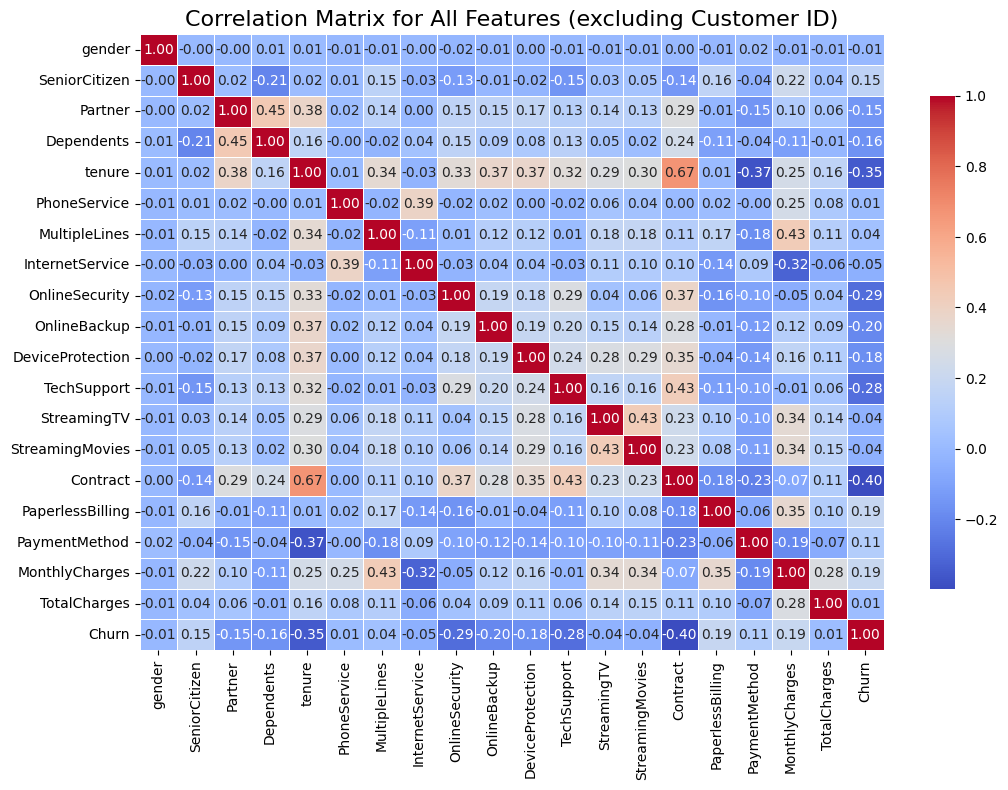

In [9]:
# Label Encoding for Categorical Columns
label_encoder = LabelEncoder()
# Exclude 'customerID' from categorical features for encoding
categorical_features = [col for col in df_telco.select_dtypes(include=['object']).columns if col != 'customerID']

for feature in categorical_features:
    df_telco[feature] = label_encoder.fit_transform(df_telco[feature])

# Drop 'customerID' before calculating the correlation matrix to exclude it
df_for_corr = df_telco.drop(columns=['customerID'], errors='ignore')

#Calculate Correlation Matrix for All Features (excluding customerID)
corr_matrix = df_for_corr.corr()

# Plot the Correlation Matrix
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix for All Features (excluding Customer ID)', fontsize=16)
plt.show()

## **Class Distributtion**

/tmp/ipython-input-3497161055.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df_telco, palette='plasma')


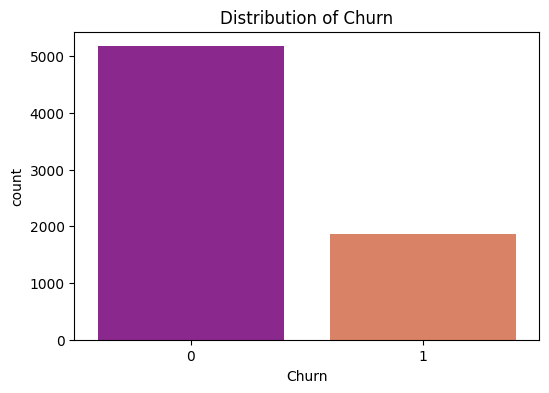

In [10]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df_telco, palette='plasma')
plt.title('Distribution of Churn')
plt.show()

## **Chrun Distribution by Class**

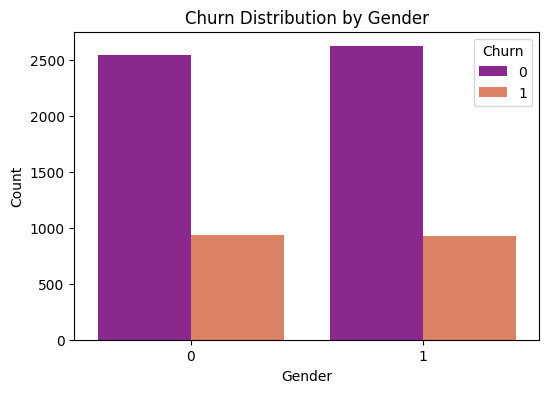

In [11]:
plt.figure(figsize=(6, 4))
sns.countplot(x='gender', hue='Churn', data=df_telco, palette='plasma')
plt.title('Churn Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

In [12]:
print("Counts for Churn column:")
print(df_telco['Churn'].value_counts())

print("\nCounts for Churn by Gender:")
print(df_telco.groupby('gender')['Churn'].value_counts())

Counts for Churn column:
Churn
0    5174
1    1869
Name: count, dtype: int64

Counts for Churn by Gender:
gender  Churn
0       0        2549
        1         939
1       0        2625
        1         930
Name: count, dtype: int64


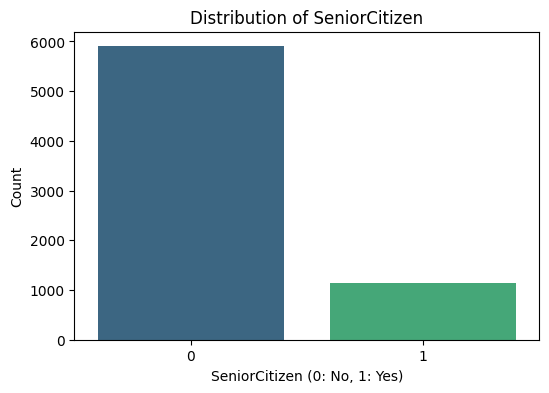

In [13]:
plt.figure(figsize=(6, 4))
sns.countplot(x='SeniorCitizen', data=df_telco, palette='viridis', hue='SeniorCitizen', legend=False)
plt.title('Distribution of SeniorCitizen')
plt.xlabel('SeniorCitizen (0: No, 1: Yes)')
plt.ylabel('Count')
plt.show()

# **Step 4: Model Training & Evaluation**

In [14]:
# %% 1) Prepare features/target from your existing df_telco (already label-encoded)
df_telco_work = df_telco.copy()

# Drop obvious IDs if present
for col in ["customerID", "CustomerID", "id", "ID"]:
    if col in df_telco_work.columns:
        df_telco_work = df_telco_work.drop(columns=[col])

# Ensure target exists and is binary numeric (0/1)
TARGET = "Churn"
assert TARGET in df_telco_work.columns, f"Target column '{TARGET}' not found."

if df_telco_work[TARGET].dtype == "O":
    df_telco_work[TARGET] = df_telco_work[TARGET].map({"No":0,"Yes":1,"0":0,"1":1})

df_telco_work = df_telco_work.dropna(subset=[TARGET])
df_telco_work[TARGET] = pd.to_numeric(df_telco_work[TARGET], errors="coerce").fillna(0).astype(int)

X_full = df_telco_work.drop(columns=[TARGET]).apply(pd.to_numeric, errors="coerce").fillna(0)
y_full = df_telco_work[TARGET].astype(int)

print("Overall class distribution:\n", y_full.value_counts().rename({0:"No Churn",1:"Churn"}))


Overall class distribution:
 Churn
No Churn    5174
Churn       1869
Name: count, dtype: int64


## **Splitting Dataset into Training and Testing sets**

In [15]:

X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42, stratify=y_full
)

print("Train distribution:", y_train.value_counts().to_dict())
print("Test  distribution:", y_test.value_counts().to_dict())

Train distribution: {0: 4139, 1: 1495}
Test  distribution: {0: 1035, 1: 374}


In [16]:
from matplotlib.colors import ListedColormap
# Initialize results list
results = []

# Output directory
OUTPUT_DIR = "churn_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# --- Custom Visualization Setup ---
# 1. Define colors: 0 -> Red (Error), 1 -> Green (Correct)
cm_cmap = ListedColormap(['#ffcccc', '#ccffcc'])

# 2. Define mask for the heatmap
color_mask = np.array([[1, 0],
                       [0, 1]])

## **Training & Evaluating Logistic Regression**


--- Running Logistic Regression ---

Classification Report for Logistic Regression:
              precision    recall  f1-score   support

    No Churn       0.84      0.89      0.87      1035
       Churn       0.64      0.53      0.58       374

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



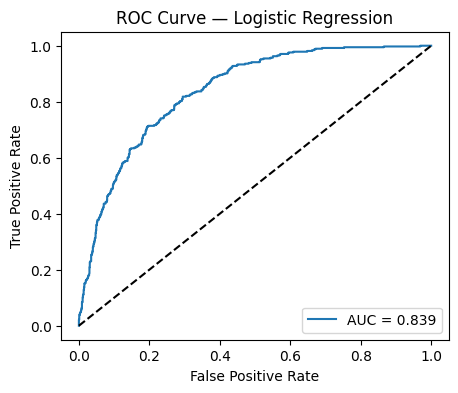

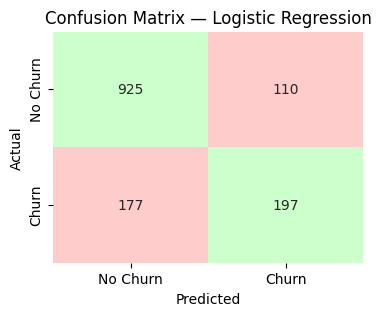

In [17]:
model_name = "Logistic Regression"
print(f"\n--- Running {model_name} ---")

#Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#Train
lr = LogisticRegression(solver="liblinear", max_iter=2000, random_state=42)
t0 = time.perf_counter()
lr.fit(X_train_scaled, y_train)
train_time = time.perf_counter() - t0

#Predict
t0 = time.perf_counter()
y_proba = lr.predict_proba(X_test_scaled)[:, 1]
y_pred = (y_proba >= 0.5).astype(int)
test_time = time.perf_counter() - t0

#Calculate Metrics
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)
pr_auc = average_precision_score(y_test, y_proba)
acc = accuracy_score(y_test, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average="binary", zero_division=0)
cm = confusion_matrix(y_test, y_pred)

# Print Classification Report
print(f"\nClassification Report for {model_name}:")
print(classification_report(y_test, y_pred, target_names=["No Churn", "Churn"]))

# Store results
results.append({
    "Model": model_name, "AUC ROC": roc_auc, "AP (PR-AUC)": pr_auc,
    "Accuracy": acc, "Precision": precision, "Recall": recall, "F1": f1,
    "Train Time": train_time, "Test Time": test_time
})

#Plot ROC Curve
plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.title(f"ROC Curve — {model_name}")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

#Plot Custom Confusion Matrix
plt.figure(figsize=(4, 3))
sns.heatmap(
    color_mask,
    annot=cm,
    fmt='d',
    cmap=cm_cmap,
    cbar=False,
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)
plt.title(f"Confusion Matrix — {model_name}")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

## **Training & Evaluating Random Forest**


--- Running Random Forest (n=400) ---

Classification Report for Random Forest (n=400):
              precision    recall  f1-score   support

    No Churn       0.83      0.90      0.86      1035
       Churn       0.64      0.50      0.56       374

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409



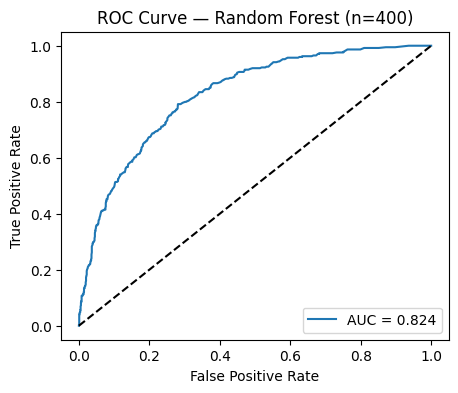

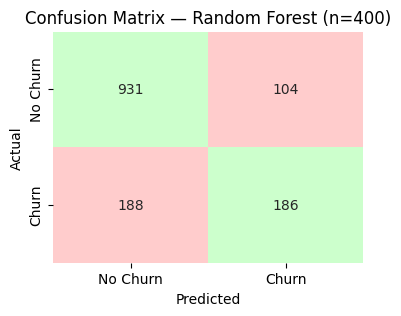

In [18]:

model_name = "Random Forest (n=400)"
print(f"\n--- Running {model_name} ---")

rf = RandomForestClassifier(n_estimators=400, random_state=42, n_jobs=-1)
t0 = time.perf_counter()
rf.fit(X_train, y_train)
train_time = time.perf_counter() - t0

# Predict
t0 = time.perf_counter()
y_proba = rf.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= 0.5).astype(int)
test_time = time.perf_counter() - t0

# Calculate Metrics
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)
pr_auc = average_precision_score(y_test, y_proba)
acc = accuracy_score(y_test, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average="binary", zero_division=0)
cm = confusion_matrix(y_test, y_pred)

# Print Classification Report
print(f"\nClassification Report for {model_name}:")
print(classification_report(y_test, y_pred, target_names=["No Churn", "Churn"]))

# Store results
results.append({
    "Model": model_name, "AUC ROC": roc_auc, "AP (PR-AUC)": pr_auc,
    "Accuracy": acc, "Precision": precision, "Recall": recall, "F1": f1,
    "Train Time": train_time, "Test Time": test_time
})

# Plot ROC Curve
plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.title(f"ROC Curve — {model_name}")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

# Plot Custom Confusion Matrix
plt.figure(figsize=(4, 3))
sns.heatmap(
    color_mask,
    annot=cm,
    fmt='d',
    cmap=cm_cmap,
    cbar=False,
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)
plt.title(f"Confusion Matrix — {model_name}")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

## **Training & Evaluating GRADIENT BOOSTING**


--- Running Gradient Boosting ---

Classification Report for Gradient Boosting:
              precision    recall  f1-score   support

    No Churn       0.83      0.91      0.87      1035
       Churn       0.66      0.50      0.57       374

    accuracy                           0.80      1409
   macro avg       0.75      0.70      0.72      1409
weighted avg       0.79      0.80      0.79      1409



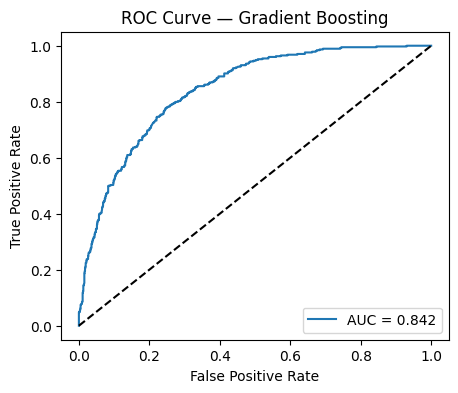

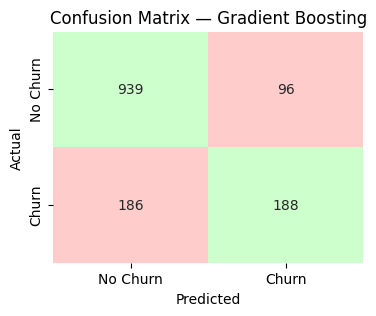

In [19]:
model_name = "Gradient Boosting"
print(f"\n--- Running {model_name} ---")


gb = GradientBoostingClassifier(random_state=42)
t0 = time.perf_counter()
gb.fit(X_train, y_train)
train_time = time.perf_counter() - t0

# Predict
t0 = time.perf_counter()
y_proba = gb.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= 0.5).astype(int)
test_time = time.perf_counter() - t0

# Calculate Metrics
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)
pr_auc = average_precision_score(y_test, y_proba)
acc = accuracy_score(y_test, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average="binary", zero_division=0)
cm = confusion_matrix(y_test, y_pred)

# Print Classification Report
print(f"\nClassification Report for {model_name}:")
print(classification_report(y_test, y_pred, target_names=["No Churn", "Churn"]))

# Store results
results.append({
    "Model": model_name, "AUC ROC": roc_auc, "AP (PR-AUC)": pr_auc,
    "Accuracy": acc, "Precision": precision, "Recall": recall, "F1": f1,
    "Train Time": train_time, "Test Time": test_time
})

# Plot ROC Curve
plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.title(f"ROC Curve — {model_name}")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

# Plot Custom Confusion Matrix
plt.figure(figsize=(4, 3))
sns.heatmap(
    color_mask,
    annot=cm,
    fmt='d',
    cmap=cm_cmap,
    cbar=False,
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)
plt.title(f"Confusion Matrix — {model_name}")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

In [20]:
# ==========================================
# RESULTS LEADERBOARD
# ==========================================
# Create DataFrame from the results list
leaderboard = pd.DataFrame(results)

# Sort by AUC ROC
leaderboard = leaderboard.sort_values(
    ["AUC ROC", "AP (PR-AUC)", "F1"], ascending=False
).reset_index(drop=True)

# Display the final table with all indicators
print("\n--- Final Model Comparison ---")
leaderboard


--- Final Model Comparison ---


,Model,AUC ROC,AP (PR-AUC),Accuracy,Precision,Recall,F1,Train Time,Test Time
0,Gradient Boosting,0.841940,0.650740,0.799858,0.661972,0.502674,0.571429,1.079761,0.004698
1,Logistic Regression,0.838888,0.630339,0.796309,0.641694,0.526738,0.578561,0.046108,0.001220
2,Random Forest (n=400),0.824253,0.620963,0.792761,0.641379,0.497326,0.560241,3.501619,0.201593


# **Step 5: SMOTE to Balance the Dataset**



Apply SMOTENC to the training data (X_train, y_train) to address class imbalance and then visualize the distribution of the 'Churn' target in the newly balanced training set.


Categorical features identified for SMOTENC: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Shape of X_train after SMOTENC: (8278, 19)
Shape of y_train after SMOTENC: (8278,)
Distribution of Churn in original y_train:
 Churn
0    4139
1    1495
Name: count, dtype: int64
Distribution of Churn in resampled y_train:
 Churn
0    4139
1    4139
Name: count, dtype: int64


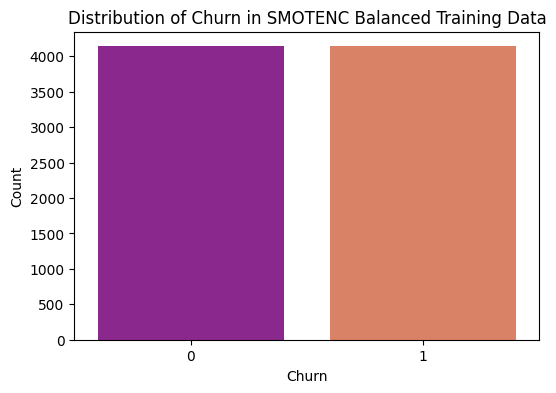

In [21]:
from imblearn.over_sampling import SMOTENC
import matplotlib.pyplot as plt
import seaborn as sns

# Identify categorical features and their indices
categorical_feature_names = [col for col in X_train.columns if X_train[col].dtype == 'int64' and X_train[col].nunique() < 20 and col != 'SeniorCitizen'] # Assuming int64 with few unique values are categorical after label encoding, excluding SeniorCitizen
categorical_feature_indices = [X_train.columns.get_loc(col) for col in categorical_feature_names]

print(f"Categorical features identified for SMOTENC: {categorical_feature_names}")

# Initialize SMOTENC
smotenc = SMOTENC(categorical_features=categorical_feature_indices, random_state=42)

# Apply SMOTENC to the training data
X_resampled, y_resampled = smotenc.fit_resample(X_train, y_train)

print("Shape of X_train after SMOTENC:", X_resampled.shape)
print("Shape of y_train after SMOTENC:", y_resampled.shape)
print("Distribution of Churn in original y_train:\n", y_train.value_counts())
print("Distribution of Churn in resampled y_train:\n", y_resampled.value_counts())

# Plot the distribution of the 'Churn' target in the newly balanced training set
plt.figure(figsize=(6, 4))
sns.countplot(x=y_resampled, hue=y_resampled, palette='plasma', legend=False)
plt.title('Distribution of Churn in SMOTENC Balanced Training Data')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.show()


--- Retraining models with SMOTE-balanced data ---


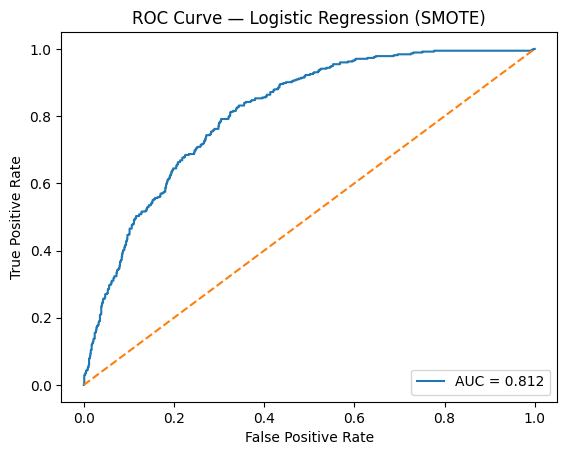

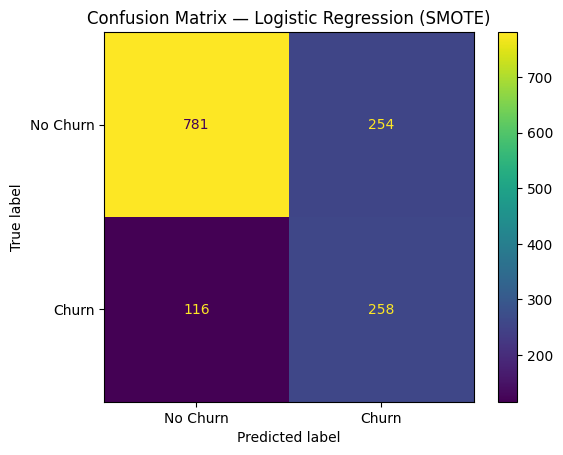

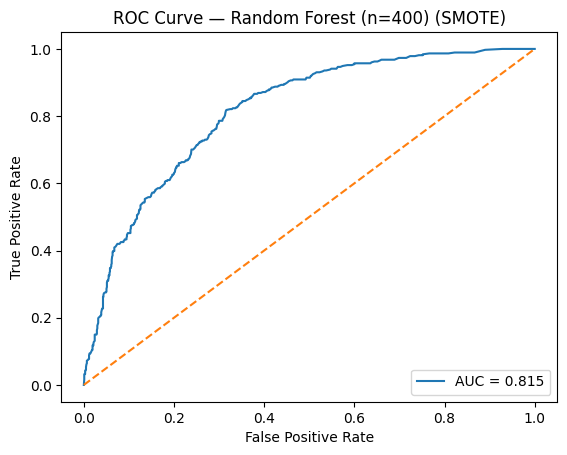

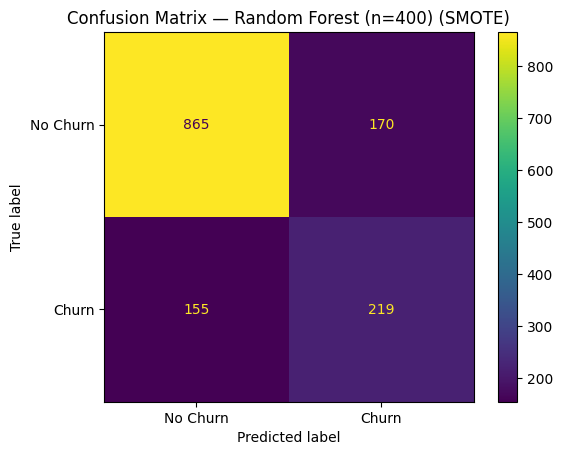

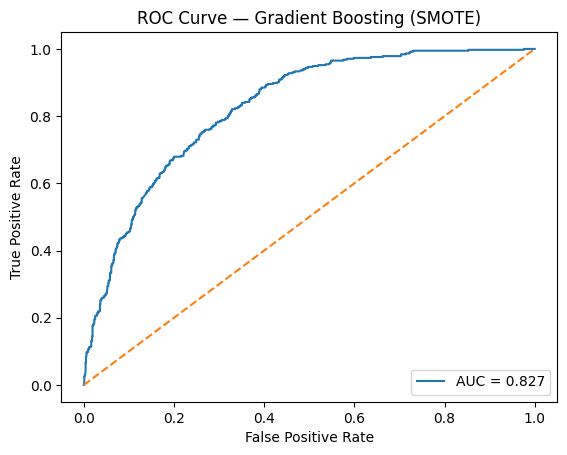

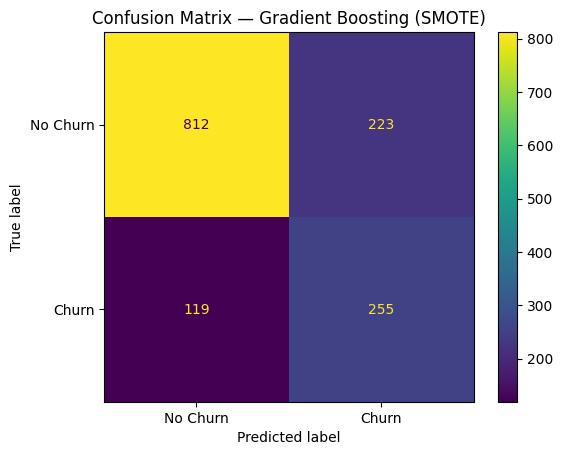

,Model,AUC ROC,AP (PR-AUC),Accuracy,Precision,Recall,F1,Train Time (s),Test Time (s),ROC Plot,CM Plot
0,Logistic Regression (SMOTE),0.812284,0.574884,0.737402,0.503906,0.689840,0.582393,0.031637,0.003505,churn_outputs/roc_logistic-regression-smote.png,churn_outputs/cm_logistic-regression-smote.png
1,Random Forest (n=400) (SMOTE),0.814747,0.589168,0.769340,0.562982,0.585561,0.574050,7.168144,0.269626,churn_outputs/roc_random-forest-n-400-smote.png,churn_outputs/cm_random-forest-n-400-smote.png
2,Gradient Boosting (SMOTE),0.827135,0.610228,0.757275,0.533473,0.681818,0.598592,1.510748,0.004910,churn_outputs/roc_gradient-boosting-smote.png,churn_outputs/cm_gradient-boosting-smote.png


In [26]:
from slugify import slugify
smote_results = [] # Initialize a new list for SMOTE-trained model results

def run_model_block_resampled(model_name, estimator, scale=False):
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    steps = []
    if scale:
        steps.append(("scaler", StandardScaler()))
    steps.append(("model", estimator))
    pipe = Pipeline(steps=steps)
    t0 = time.perf_counter()
    # Train with resampled data
    pipe.fit(X_resampled, y_resampled)
    train_time = time.perf_counter() - t0
    t0 = time.perf_counter()
    # Evaluate on original test data
    if hasattr(pipe.named_steps["model"], "predict_proba"):
        y_proba = pipe.predict_proba(X_test)[:, 1]
    else:
        y_score = pipe.decision_function(X_test)
        y_proba = (y_score - y_score.min()) / (y_score.max() - y_score.min() + 1e-12)
    y_pred = (y_proba >= 0.5).astype(int)
    test_time = time.perf_counter() - t0
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    pr_auc  = average_precision_score(y_test, y_proba)
    acc     = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, y_pred, average="binary", zero_division=0
    )
    cm = confusion_matrix(y_test, y_pred)
    tag = slugify(f"{model_name}_smote") # Add '_smote' to the tag for distinct filenames

    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve \u2014 {model_name} (SMOTE)")
    plt.legend(loc="lower right")
    roc_path = os.path.join(OUTPUT_DIR, f"roc_{tag}.png")
    plt.savefig(roc_path, dpi=150, bbox_inches="tight")

    plt.show()

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Churn", "Churn"])
    disp.plot(values_format="d")
    plt.title(f"Confusion Matrix \u2014 {model_name} (SMOTE)")
    cm_path = os.path.join(OUTPUT_DIR, f"cm_{tag}.png")
    plt.savefig(cm_path, dpi=150, bbox_inches="tight")
    plt.show()

    return {
        "Model": f"{model_name} (SMOTE)", # Update model name for clarity
        "AUC ROC": roc_auc,
        "AP (PR-AUC)": pr_auc,
        "Accuracy": acc,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "Train Time (s)": train_time,
        "Test Time (s)": test_time,
        "ROC Plot": roc_path,
        "CM Plot": cm_path,

    }


# Run models with SMOTE-balanced training data

print("\n--- Retraining models with SMOTE-balanced data ---")

# Logistic Regression with SMOTE
res_lr_smote = run_model_block_resampled(
    "Logistic Regression",
    LogisticRegression(solver="liblinear", max_iter=2000, random_state=42),
    scale=True
)
smote_results.append(res_lr_smote)

# Random Forest with SMOTE
res_rf_smote = run_model_block_resampled(
    "Random Forest (n=400)",
    RandomForestClassifier(n_estimators=400, random_state=42, n_jobs=-1),
    scale=False

)

smote_results.append(res_rf_smote)

# Gradient Boosting with SMOTE
res_gb_smote = run_model_block_resampled(
    "Gradient Boosting",
    GradientBoostingClassifier(random_state=42),
    scale=False
)

smote_results.append(res_gb_smote)

# Create SMOTE leaderboard from results
leaderboard_smote = pd.DataFrame(smote_results)

# Display new leaderboard
leaderboard_smote


# **Step 6: Cross Validation using K-Fold**

In [27]:
from sklearn.model_selection import StratifiedKFold, cross_validate

models_cv = {
    "Logistic Regression": Pipeline([("scaler", StandardScaler()),
                                     ("model", LogisticRegression(solver="liblinear", max_iter=2000, random_state=42))]),

    "Random Forest (n=400)": Pipeline([("model", RandomForestClassifier(n_estimators=400, random_state=42, n_jobs=-1))]),
    "Gradient Boosting": Pipeline([("model", GradientBoostingClassifier(random_state=42))]),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {
    "roc_auc": "roc_auc",
    "accuracy": "accuracy",
    "f1": "f1",
    "precision": "precision",
    "recall": "recall"
}

rows = []
for name, pipe in models_cv.items():
    cv_res = cross_validate(pipe, X_full, y_full, cv=cv, scoring=scoring, n_jobs=-1, return_train_score=False)
    rows.append({
        "Model": name,
        "ROC AUC (mean)": np.mean(cv_res["test_roc_auc"]),
        "ROC AUC (std)":  np.std(cv_res["test_roc_auc"]),
        "Accuracy (mean)": np.mean(cv_res["test_accuracy"]),
        "F1 (mean)": np.mean(cv_res["test_f1"]),
        "Precision (mean)": np.mean(cv_res["test_precision"]),
        "Recall (mean)": np.mean(cv_res["test_recall"]),
    })

cv_table = pd.DataFrame(rows).sort_values(["ROC AUC (mean)", "F1 (mean)"], ascending=False).reset_index(drop=True)

cv_csv = os.path.join(OUTPUT_DIR, "cv_results.csv")
cv_table.to_csv(cv_csv, index=False)
print("Saved cross-validation results to:", cv_csv)
cv_table


Saved cross-validation results to: churn_outputs/cv_results.csv


,Model,ROC AUC (mean),ROC AUC (std),Accuracy (mean),F1 (mean),Precision (mean),Recall (mean)
0,Gradient Boosting,0.847092,0.011542,0.802780,0.581726,0.664630,0.517373
1,Logistic Regression,0.842565,0.014896,0.804057,0.592698,0.660074,0.538226
2,Random Forest (n=400),0.826000,0.012623,0.789007,0.550504,0.631680,0.488469


# **Step 7: Optimizing the Models with Grid Search**

In [28]:
from sklearn.model_selection import GridSearchCV

def tune_and_evaluate(model_name, pipeline, param_grid, results_list, cv=5):
    """
    Performs GridSearchCV, evaluates the best model on the test set,
    generates plots, and appends metrics to the global results list.
    """
    print(f"\n--- Tuning {model_name} ---")

    # 1. Grid Search (Training)
    t0 = time.perf_counter()
    grid = GridSearchCV(
        pipeline,
        param_grid,
        cv=cv,
        scoring='roc_auc',
        n_jobs=-1,
        verbose=1
    )
    grid.fit(X_train, y_train)
    train_time = time.perf_counter() - t0

    print(f"Best Params: {grid.best_params_}")
    print(f"Best CV ROC-AUC: {grid.best_score_:.4f}")

    best_model = grid.best_estimator_

    # 2. Prediction (Test Set)
    t1 = time.perf_counter()
    if hasattr(best_model.named_steps['model'], "predict_proba"):
        y_proba = best_model.predict_proba(X_test)[:, 1]
    else:
        y_score = best_model.decision_function(X_test)
        y_proba = (y_score - y_score.min()) / (y_score.max() - y_score.min() + 1e-12)

    y_pred = (y_proba >= 0.5).astype(int)
    test_time = time.perf_counter() - t1

    # 3. Calculate Metrics
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    pr_auc  = average_precision_score(y_test, y_proba)
    acc     = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, y_pred, average="binary", zero_division=0
    )
    cm = confusion_matrix(y_test, y_pred)

    # 4. Generate Plots (Same as run_model_block)
    tag = slugify(f"{model_name}_tuned")

    # ROC Plot
    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve — {model_name} (Tuned)")
    plt.legend(loc="lower right")
    roc_path = os.path.join(OUTPUT_DIR, f"roc_{tag}.png")
    plt.savefig(roc_path, dpi=150, bbox_inches="tight")
    plt.show()

    # Confusion Matrix Plot
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Churn", "Churn"])
    disp.plot(values_format="d")
    plt.title(f"Confusion Matrix — {model_name} (Tuned)")
    cm_path = os.path.join(OUTPUT_DIR, f"cm_{tag}.png")
    plt.savefig(cm_path, dpi=150, bbox_inches="tight")
    plt.show()

    # 5. Compile Result Dictionary
    # We include 'Best Params' and 'CV Score' as extra columns
    res_dict = {
        "Model": f"{model_name} (Tuned)",
        "AUC ROC": roc_auc,
        "AP (PR-AUC)": pr_auc,
        "Accuracy": acc,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "Train Time (s)": train_time,
        "Test Time (s)": test_time,
        "Best Params": str(grid.best_params_),
        "CV ROC AUC": grid.best_score_,
        "ROC Plot": roc_path,
        "CM Plot": cm_path,
    }

    # Store in the global list
    results_list.append(res_dict)
    return best_model

## **Defining the models**

In [29]:
param_grids = {
    "Logistic Regression": {
        "estimator": LogisticRegression(solver="liblinear", random_state=42),
        "scale": True,
        "params": {
            "model__C": [0.01, 0.1, 1, 10],
            "model__penalty": ["l1", "l2"]
        }
    },



    "Random Forest": {
        "estimator": RandomForestClassifier(random_state=42, n_jobs=-1),
        "scale": False,
        "params": {
            "model__n_estimators": [200, 400],
            "model__max_depth": [None, 10, 20],
            "model__min_samples_leaf": [1, 2]
        }
    },

    "Gradient Boosting": {
        "estimator": GradientBoostingClassifier(random_state=42),
        "scale": False,
        "params": {
            "model__n_estimators": [100, 200],
            "model__learning_rate": [0.05, 0.1, 0.2],
            "model__max_depth": [3, 5]
        }
    }
}

## **Running the optimization Loop**


--- Tuning Logistic Regression ---
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best Params: {'model__C': 0.1, 'model__penalty': 'l1'}
Best CV ROC-AUC: 0.8439


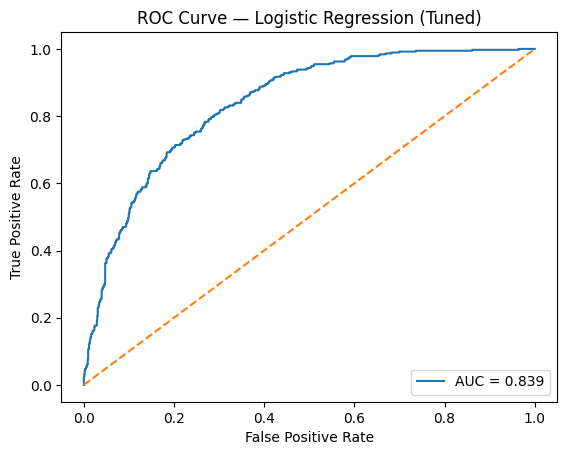

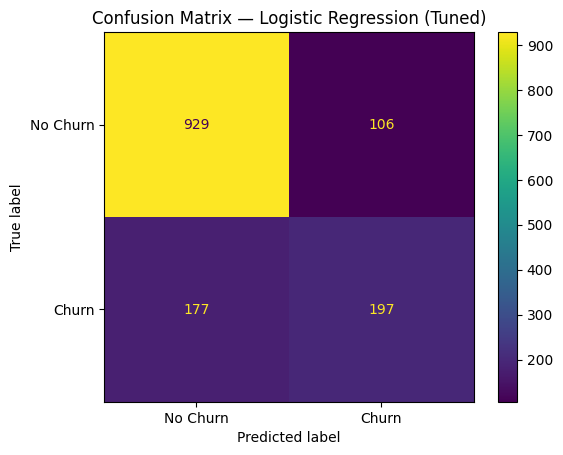


--- Tuning Random Forest ---
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best Params: {'model__max_depth': 10, 'model__min_samples_leaf': 2, 'model__n_estimators': 200}
Best CV ROC-AUC: 0.8429


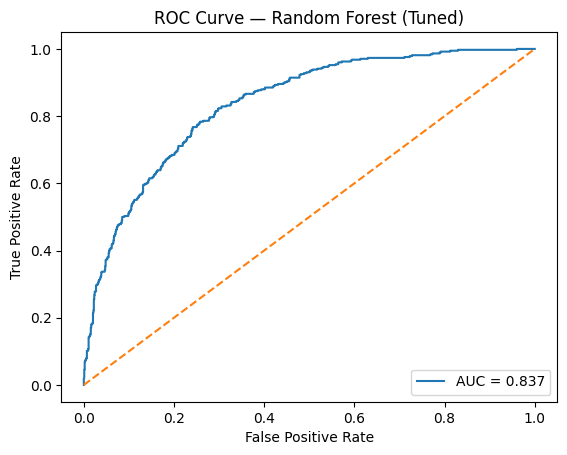

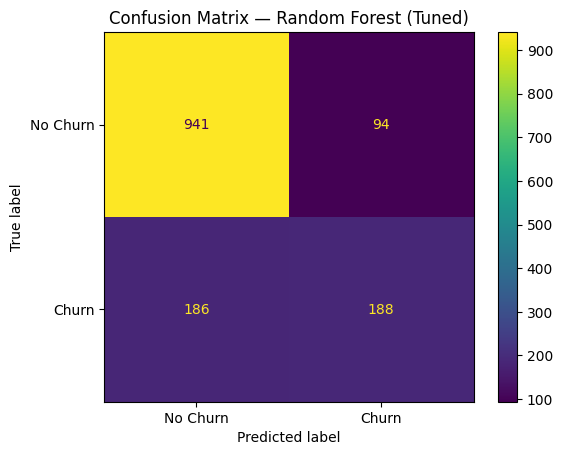


--- Tuning Gradient Boosting ---
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best Params: {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 100}
Best CV ROC-AUC: 0.8469


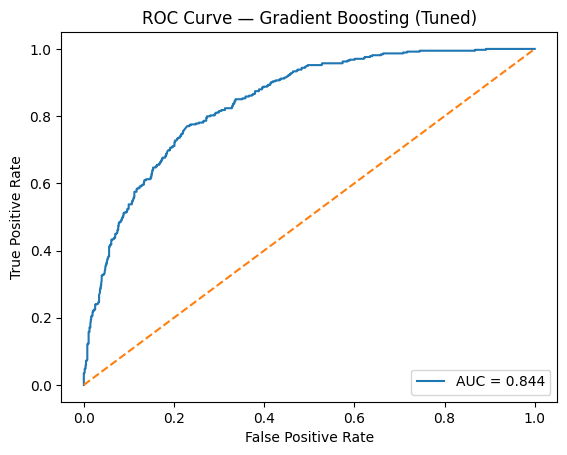

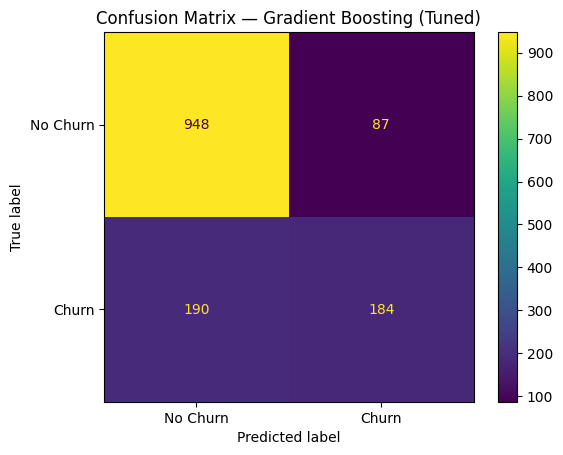


--- Tuning Complete. Total models in results: 6 ---


In [30]:
# Dictionary to store the actual best model objects for later saving
tuned_models_registry = {}

for name, config in param_grids.items():
    # Construct pipeline
    steps = []
    if config["scale"]:
        steps.append(("scaler", StandardScaler()))
    steps.append(("model", config["estimator"]))

    pipe = Pipeline(steps)

    # Run tuning (this automatically appends to 'results')
    best_model = tune_and_evaluate(name, pipe, config["params"], results)

    # Save the model object in a separate dict if needed for export
    tuned_models_registry[name] = best_model

print(f"\n--- Tuning Complete. Total models in results: {len(results)} ---")

## **Comparision Metrics**

In [31]:
# %% 4) Generate Final Leaderboard (ROC AUC, Accuracy, F1, Recall)

# Create combined dataframe from the global 'results' list
final_leaderboard = pd.DataFrame(results)

# Sort by F1 Score (descending) to highlight best balance of precision/recall
final_leaderboard = final_leaderboard.sort_values("F1", ascending=False).reset_index(drop=True)

# Select only the requested columns
cols_to_keep = ["Model", "AUC ROC", "Accuracy", "F1", "Recall"]
simple_leaderboard = final_leaderboard[cols_to_keep]

# Save the table
simple_csv_path = os.path.join(OUTPUT_DIR, "final_model_metrics_selected.csv")
simple_leaderboard.to_csv(simple_csv_path, index=False)

print("Saved selected metrics to:", simple_csv_path)

# Display the table
simple_leaderboard

Saved selected metrics to: churn_outputs/final_model_metrics_selected.csv


,Model,AUC ROC,Accuracy,F1,Recall
0,Logistic Regression (Tuned),0.839058,0.799148,0.581979,0.526738
1,Logistic Regression,0.838888,0.796309,0.578561,0.526738
2,Random Forest (Tuned),0.837383,0.801278,0.573171,0.502674
3,Gradient Boosting,0.841940,0.799858,0.571429,0.502674
4,Gradient Boosting (Tuned),0.843906,0.803407,0.570543,0.491979
5,Random Forest (n=400),0.824253,0.792761,0.560241,0.497326


# **Step 8: Advanced Analysis**


Re-training Gradient Boosting model for analysis...
Training complete. Proceeding to plots.


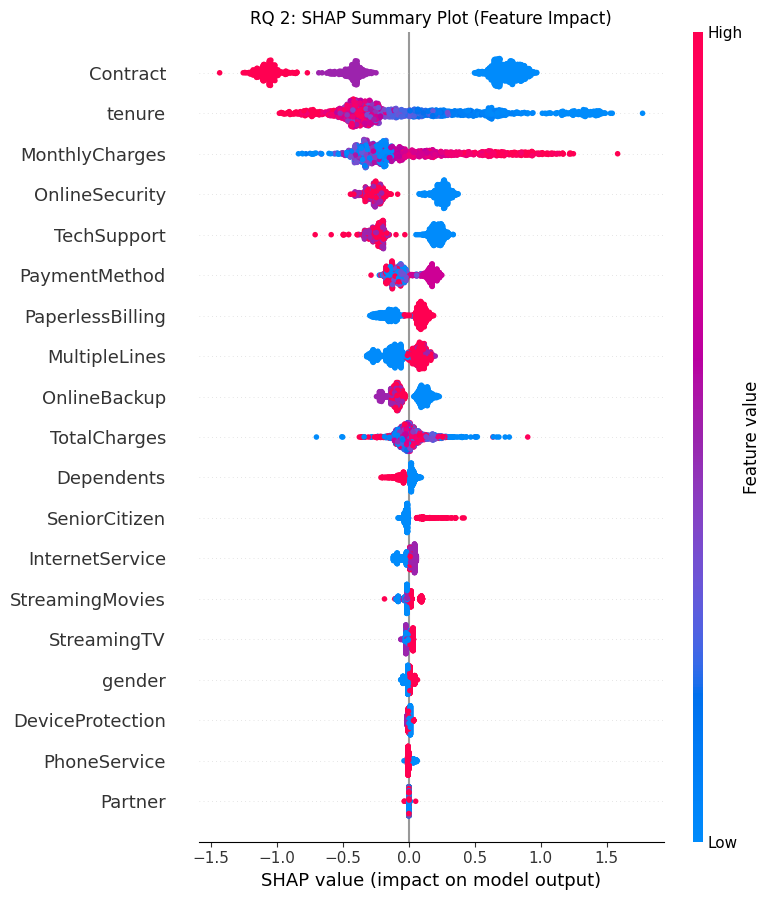

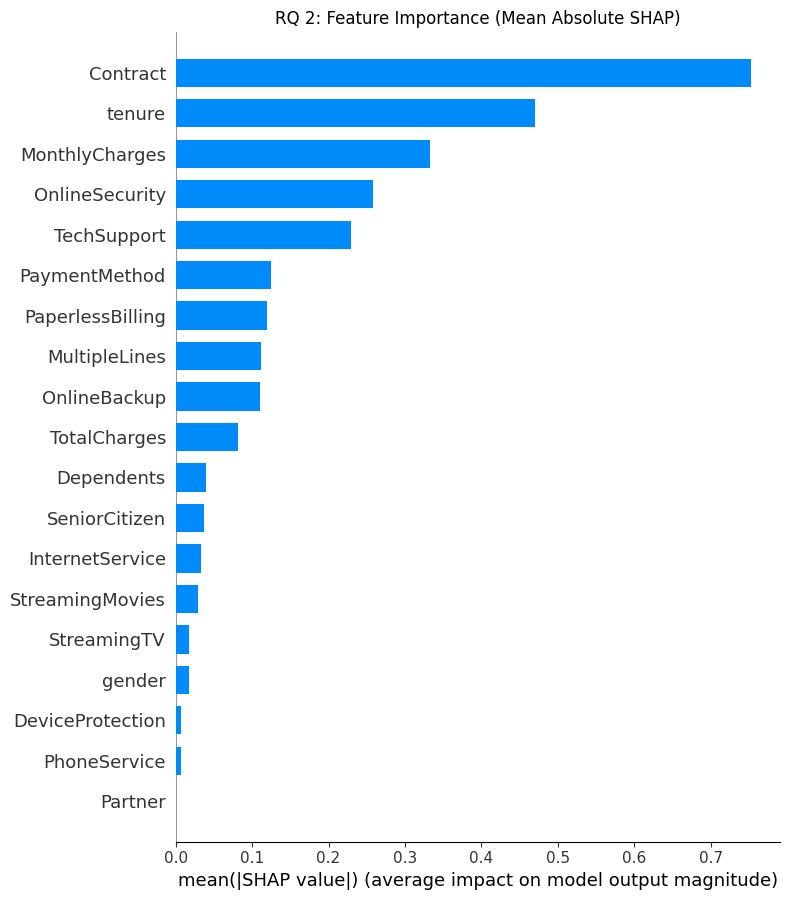


--- Generating RQ 3 Calibration & Threshold Plots ---


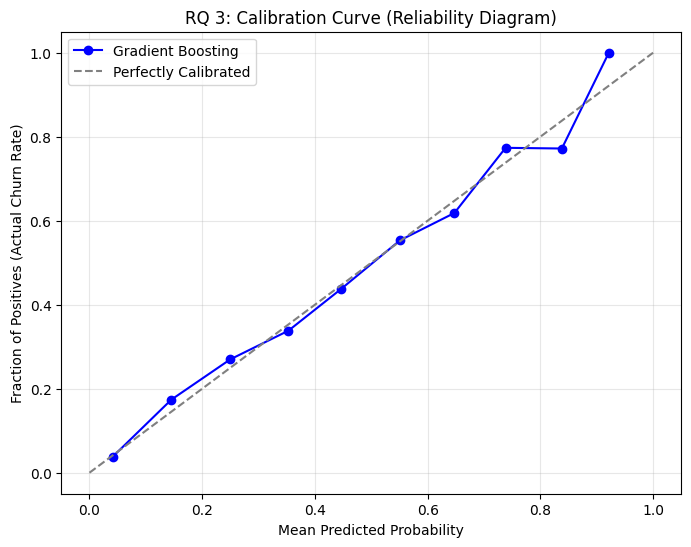

Optimal Threshold Tuning Results:
---------------------------------
Best Threshold:   0.3236
Best F1-Score:    0.6327
Default (0.5) F1: 0.5714


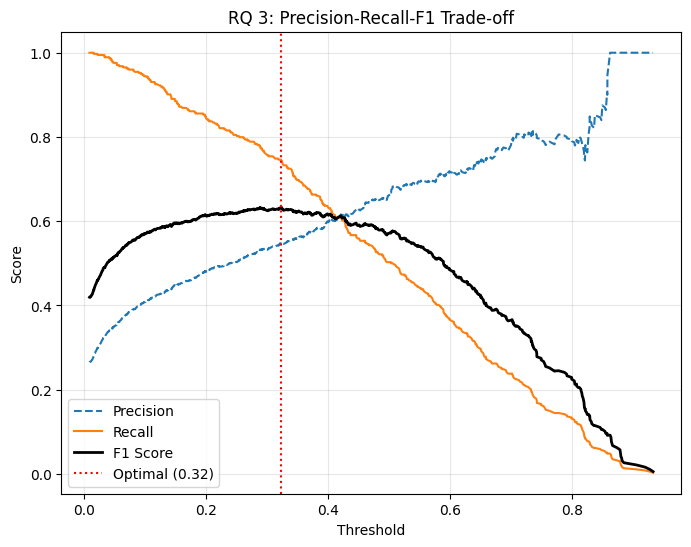

In [32]:
import shap
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.calibration import calibration_curve
from sklearn.metrics import precision_recall_curve, f1_score
import numpy as np

print("Re-training Gradient Boosting model for analysis...")
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train, y_train)
print("Training complete. Proceeding to plots.")


# 1. Initialize Explainer (Gradient Boosting is tree-based)
explainer = shap.TreeExplainer(gb_model)

# 2. Calculate SHAP values
shap_values = explainer.shap_values(X_test)

# 3. SHAP Summary Plot
plt.figure(figsize=(10, 6))
plt.title("RQ 2: SHAP Summary Plot (Feature Impact)")
shap.summary_plot(shap_values, X_test, show=False)
plt.tight_layout()
plt.show()

# 4. SHAP Bar Plot
plt.figure(figsize=(10, 6))
plt.title("RQ 2: Feature Importance (Mean Absolute SHAP)")
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.tight_layout()
plt.show()

# ==============================================================================
# RQ 3: Threshold Tuning & Probability Calibration
# ==============================================================================
print("\n--- Generating RQ 3 Calibration & Threshold Plots ---")

# 1. Get Probabilities
y_proba_gb = gb_model.predict_proba(X_test)[:, 1]

# --- Part A: Calibration Curve ---
prob_true, prob_pred = calibration_curve(y_test, y_proba_gb, n_bins=10)

plt.figure(figsize=(8, 6))
plt.plot(prob_pred, prob_true, marker='o', label='Gradient Boosting', color='blue')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly Calibrated')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives (Actual Churn Rate)')
plt.title('RQ 3: Calibration Curve (Reliability Diagram)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# --- Part B: Threshold Tuning ---
precision, recall, thresholds = precision_recall_curve(y_test, y_proba_gb)

# Calculate F1 for all thresholds (add epsilon to avoid div by zero)
fscore = (2 * precision * recall) / (precision + recall + 1e-12)
ix = np.argmax(fscore)

best_thresh = thresholds[ix]
best_f1 = fscore[ix]

# Compare with default 0.5 threshold
y_default = (y_proba_gb >= 0.5).astype(int)
default_f1 = f1_score(y_test, y_default)

print(f"Optimal Threshold Tuning Results:")
print(f"---------------------------------")
print(f"Best Threshold:   {best_thresh:.4f}")
print(f"Best F1-Score:    {best_f1:.4f}")
print(f"Default (0.5) F1: {default_f1:.4f}")

plt.figure(figsize=(8, 6))
plt.plot(thresholds, precision[:-1], label='Precision', linestyle='--')
plt.plot(thresholds, recall[:-1], label='Recall', linestyle='-')
plt.plot(thresholds, fscore[:-1], label='F1 Score', color='black', linewidth=2)
plt.axvline(best_thresh, color='red', linestyle=':', label=f'Optimal ({best_thresh:.2f})')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('RQ 3: Precision-Recall-F1 Trade-off')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()